# Toy model: one spin, four sites, a hybrid walk

`toy_single_spin_relaxation` had one site, so the only thing to sample was
the spin's offset from its table value. Here there are four sites, and the
sampler alternates two kinds of move:

- a **discrete** move, which puts the spin on a different site;
- a **continuous** move, which changes one component of its offset
  $(\delta_\parallel, \delta_\perp)$ from that site's table value.

Every site allows the same rectangle of offsets, ±10 kHz in $A_\parallel$ and
±5 kHz in $A_\perp$, with a flat prior inside it. The data are simulated from
a spin on site 0 at (105, 52) kHz, which is site 0's table value of
(100, 50) plus an offset of (+5, +2).

The offset belongs to the spin, not to the site. When the spin hops, its
offset goes with it: a spin sitting at $+5$ kHz from one table value lands
at $+5$ kHz from the next. That is how the package's site move behaves, and
it is what couples the two walks.

Two lattices are run. In the first the four rectangles are far apart in
coupling space; in the second they overlap.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

from nuclear_spin_recovery import (
    RWMH,
    AnalyticCCE1,
    ContinuousReflected,
    DiscreteLatticeWalk,
    Envelope,
    Experiment,
    ExperimentSet,
    GaussianL2,
    HybridDriver,
    NeighborIndex,
    ParameterBlock,
    Schedule,
    SiteTable,
    State,
    Step,
    Target,
    Trace,
    gyromagnetic_ratio,
    simulate_coherence,
    simulate_dataset,
)

# One colour per site, the same in every figure.  The start, the target and
# the recovered value are drawn in ink with distinct marker shapes, so they
# are never confused with a site.
SITE_COLOURS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
C_RECOVERED = "#4a3aa7"
C_INK, C_MUTED, C_GRID, C_AXIS = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": C_AXIS, "axes.labelcolor": "#52514e",
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
    "grid.color": C_GRID, "grid.linewidth": 0.6, "legend.frameon": False,
    "figure.dpi": 110,
})

## 1. Shared pieces

No decoherence envelope, as in the one-site notebook: the forward model is
given an envelope that is one everywhere.

The experiment is CPMG-4. With 16 pulses the dips in the signal are so narrow
that the likelihood has a sharp spike at the right coupling and is rugged
everywhere else, and a single chain locks onto whichever site it reaches
first: over twelve seeds it ended on the right site seven times. Four pulses
give broader dips and a landscape one chain can cross.

In [2]:
HALF_PAR, HALF_PERP = 10.0, 5.0        # kHz, half-widths of every rectangle
TRUE_SITE, TRUE_OFFSET = 0, (5.0, 2.0)
DATA_NOISE, LIK_SIGMA = 0.002, 0.02
N_PULSES, B_Z = 4, 311.0
tau = np.linspace(3.2e-5, 8e-3, 250)   # ms
blank = ExperimentSet([Experiment(tau=tau, n_pulses=N_PULSES, b_z=B_Z)])

# Real-space positions only decide which sites are neighbours.  The four sit
# on a 2 Angstrom square and the walk radius reaches all of them, so the spin
# can hop from any site to any other.
POSITIONS = np.array([[0.0, 0.0, 2.0], [2.0, 0.0, 2.0],
                      [0.0, 2.0, 2.0], [2.0, 2.0, 2.0]])
HOP_RADIUS = 5.0


class NoEnvelope(Envelope):
    """No attenuation: the coherence is the spin modulation alone."""

    def __call__(self, tau, exp_id, lam, n_stretch):
        return np.ones_like(np.asarray(tau, dtype=float))


class RectangleOffsets(RWMH):
    """Offset walk with a flat prior on a rectangle, one component per step.

    The package's ``GaussianOffset`` has one bound for both components and a
    Gaussian prior; this replaces only the proposal, as in the one-site
    notebook.
    """

    def __init__(self, par, perp):
        super().__init__(ParameterBlock("offsets"), par)
        self.proposals = (par, perp)

    def _propose_offsets(self, state, rng):
        which = int(rng.integers(2))
        values = state.dA_par if which == 0 else state.dA_perp
        log_ratio = np.zeros(state.n_replicas)
        for r in range(state.n_replicas):
            proposed, log_ratio[r] = self.proposals[which].propose(
                rng, float(values[r, 0]))
            values[r, 0] = float(proposed)
        return log_ratio


model = AnalyticCCE1(NoEnvelope())

## 2. One run

The schedule is the package's hybrid driver: one site move, then five offset
moves, repeated. The site move is the package's own `RWMH` over the `sites`
block with a `DiscreteLatticeWalk`, unmodified.

In [3]:
N_STEPS, N_BURN = 12000, 2000
SITE_STEPS, OFFSET_STEPS = 1, 5
STEP_KHZ = 1.0


def run_walk(centres, start_site, seed):
    """Simulate data on ``centres`` and run the hybrid walk from ``start_site``.

    ``centres`` is the (A_par, A_perp) table value of each of the four sites.
    Returns the walk in arrays that include the starting point at index 0.
    """
    centres = np.asarray(centres, dtype=float)
    table = SiteTable(
        distance=np.linalg.norm(POSITIONS, axis=1), positions=POSITIONS,
        a_par=centres[:, 0], a_perp=centres[:, 1],
        isotope=np.array(["13C"] * 4),
        gyro=np.full(4, gyromagnetic_ratio("13C")))

    def make_state(site, d_par=0.0, d_perp=0.0):
        state = State.from_sites(
            (site,), n_sites=4, n_exp=1,
            # A State must carry a decay constant; NoEnvelope never reads it.
            lam=np.ones((1, 1)), n_stretch=np.ones((1, 1)),
            sigma=np.full((1, 1), LIK_SIGMA), k_max=1)
        state.dA_par[0, 0] = d_par
        state.dA_perp[0, 0] = d_perp
        return state

    truth = make_state(TRUE_SITE, *TRUE_OFFSET)
    data = simulate_dataset(truth, blank, table, model, sigma=DATA_NOISE,
                            rng=np.random.default_rng(3))
    target = Target(data, model, GaussianL2(), table)

    schedule = Schedule([
        Step(RWMH(ParameterBlock("sites"),
                  DiscreteLatticeWalk(NeighborIndex(POSITIONS, HOP_RADIUS))),
             SITE_STEPS),
        Step(RectangleOffsets(
            ContinuousReflected(STEP_KHZ, lower=-HALF_PAR, upper=HALF_PAR),
            ContinuousReflected(STEP_KHZ, lower=-HALF_PERP, upper=HALF_PERP)),
            OFFSET_STEPS),
    ])
    initial = make_state(start_site)
    trace = Trace(n_sites=4, k_max=1, n_exp=1)
    HybridDriver(schedule).run(initial, target, np.random.default_rng(seed),
                               N_STEPS, trace=trace)

    # The trace records the state after each step; put the start at the front.
    site = np.concatenate([[start_site], trace.site_idx[:, 0]])
    d_par = np.concatenate([[0.0], trace.dA_par[:, 0]])
    d_perp = np.concatenate([[0.0], trace.dA_perp[:, 0]])
    log_like = np.concatenate([target.log_prob(initial),
                               np.asarray(trace.log_prob)])

    best = N_BURN + int(np.argmax(log_like[N_BURN:]))
    recovered = make_state(site[best], d_par[best], d_perp[best])
    return {
        "centres": centres, "start_site": start_site,
        "site": site, "d_par": d_par, "d_perp": d_perp,
        "a_par": centres[site, 0] + d_par, "a_perp": centres[site, 1] + d_perp,
        "log_like": log_like, "best": best,
        "true_coupling": centres[TRUE_SITE] + np.array(TRUE_OFFSET),
        "measured": data.data_all,
        "signal_initial": simulate_coherence(initial, blank, table, model),
        "signal_recovered": simulate_coherence(recovered, blank, table, model),
    }


def report(res):
    site, best = res["site"], res["best"]
    hops = np.flatnonzero(np.diff(site) != 0)
    kept = site[N_BURN:]
    print(f"site hops: {hops.size} in {N_STEPS} steps "
          f"({(hops >= N_BURN).sum()} after burn-in)")
    print("share of steps after burn-in, by site: "
          + ", ".join(f"site {i}: {np.mean(kept == i):.0%}" for i in range(4)))
    t = res["true_coupling"]
    print(f"target   : site {TRUE_SITE} at ({t[0]:.2f}, {t[1]:.2f}) kHz")
    print(f"recovered: site {site[best]} at ({res['a_par'][best]:.2f}, "
          f"{res['a_perp'][best]:.2f}) kHz, offset "
          f"({res['d_par'][best]:+.2f}, {res['d_perp'][best]:+.2f}), "
          f"log-likelihood {res['log_like'][best]:.2f}")

## 3. Figures

Three views of the same walk, and one of the signals.

- **Coupling space.** Each site's rectangle of allowed couplings, the samples
  coloured by the site the spin was on, and a line for every hop.
- **Across sites.** Which site the spin is on at each step, with the misfit
  underneath: the opening steps on the left, the whole run on the right.
- **Within sites.** One panel per site, in that site's own offset
  coordinates.

In [4]:
def _markers(ax, res, offset_of=None):
    """Start, target and recovered value, in absolute or per-site coordinates."""
    c, best = res["centres"], res["best"]
    start = c[res["start_site"]]
    rec = np.array([res["a_par"][best], res["a_perp"][best]])
    shift = np.zeros(2) if offset_of is None else c[offset_of]
    for point, marker, size, face, name in [
        (start, "o", 70, C_INK, "start"),
        (res["true_coupling"], "*", 230, C_INK, "target"),
        (rec, "D", 190, "none", "recovered"),
    ]:
        if offset_of is not None:
            inside = (abs(point[0] - shift[0]) <= HALF_PAR
                      and abs(point[1] - shift[1]) <= HALF_PERP)
            if not inside:
                continue
        ax.scatter([point[0] - shift[0]], [point[1] - shift[1]], s=size,
                   marker=marker, facecolor=face,
                   edgecolor=C_RECOVERED if name == "recovered" else "white",
                   linewidths=2.2 if name == "recovered" else 1.2, zorder=6,
                   label=f"{name} ({point[0]:.1f}, {point[1]:.1f})")


def plot_coupling_space(res, title):
    c, site = res["centres"], res["site"]
    fig, ax = plt.subplots(figsize=(10.5, 5.6))
    for i in range(4):
        ax.add_patch(Rectangle(
            (c[i, 0] - HALF_PAR, c[i, 1] - HALF_PERP), 2 * HALF_PAR,
            2 * HALF_PERP, facecolor=SITE_COLOURS[i], alpha=0.10, zorder=0))
        ax.add_patch(Rectangle(
            (c[i, 0] - HALF_PAR, c[i, 1] - HALF_PERP), 2 * HALF_PAR,
            2 * HALF_PERP, facecolor="none", edgecolor=SITE_COLOURS[i],
            lw=1.6, zorder=1))
        ax.scatter([c[i, 0]], [c[i, 1]], marker="+", s=60,
                   color=SITE_COLOURS[i], zorder=2)
        on = site == i
        ax.scatter(res["a_par"][on], res["a_perp"][on], s=5,
                   color=SITE_COLOURS[i], alpha=0.35, linewidths=0, zorder=3)
        # A separate, larger handle: the sample dots are too small to read
        # in a legend.
        ax.scatter([], [], s=45, marker="s", color=SITE_COLOURS[i],
                   label=f"site {i}, table ({c[i, 0]:.0f}, {c[i, 1]:.0f})")
    hops = np.flatnonzero(np.diff(site) != 0)
    for n, h in enumerate(hops):
        ax.plot(res["a_par"][h: h + 2], res["a_perp"][h: h + 2], color=C_INK,
                lw=0.7, alpha=0.45, zorder=4,
                label=f"site hop ({hops.size})" if n == 0 else None)
    _markers(ax, res)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$A_\parallel$ (kHz)")
    ax.set_ylabel(r"$A_\perp$ (kHz)")
    ax.set_title(title, loc="left", color=C_INK)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
    fig.tight_layout()
    plt.show()


def plot_across_sites(res, opening=60):
    """Site and misfit against step: the opening steps, then the whole run.

    The first hops happen within a few steps of the start, where they would be
    a single pixel on the scale of the whole run.
    """
    site, steps = res["site"], np.arange(len(res["site"]))
    fig, axes = plt.subplots(
        2, 2, figsize=(11.5, 5.0), sharex="col", sharey="row",
        gridspec_kw={"width_ratios": [1, 2.6], "hspace": 0.12, "wspace": 0.05})
    for column, last in enumerate((opening, len(steps) - 1)):
        top, bottom = axes[0, column], axes[1, column]
        show = steps <= last
        for ax in (top, bottom):
            ax.axvspan(0, min(N_BURN, last), color="#f0efec", zorder=0)
            ax.set_xlim(0, last)
        for i in range(4):
            on = (site == i) & show
            top.scatter(steps[on], site[on], marker="|", s=120, linewidths=0.8,
                        color=SITE_COLOURS[i], zorder=2)
        if column == 0:
            top.plot(steps[show], site[show], color=C_INK, lw=0.6, zorder=1)
        bottom.plot(steps[show], -res["log_like"][show], color=C_INK, lw=0.8,
                    zorder=2)
        bottom.set_yscale("log")
        bottom.grid(axis="y")
        bottom.set_xlabel("step")
        top.set_title(f"first {opening} steps" if column == 0 else
                      f"whole run, burn-in shaded ({N_BURN} steps)",
                      loc="left", color="#52514e", fontsize=10)
    axes[0, 0].set_yticks(range(4), [f"site {i}" for i in range(4)])
    axes[0, 0].set_ylim(-0.6, 3.6)
    axes[1, 0].set_ylabel("− log-likelihood")
    fig.suptitle("Across sites: where the spin is, step by step", x=0.01,
                 ha="left", color=C_INK)
    plt.show()


def plot_within_sites(res):
    site, kept = res["site"], np.arange(len(res["site"])) >= N_BURN
    fig, axes = plt.subplots(1, 4, figsize=(13.0, 2.9), sharex=True,
                             sharey=True, layout="constrained")
    for i, ax in enumerate(axes):
        ax.add_patch(Rectangle((-HALF_PAR, -HALF_PERP), 2 * HALF_PAR,
                               2 * HALF_PERP, facecolor=SITE_COLOURS[i],
                               alpha=0.10, zorder=0))
        early, late = (site == i) & ~kept, (site == i) & kept
        ax.scatter(res["d_par"][early], res["d_perp"][early], s=5,
                   color=C_MUTED, alpha=0.5, linewidths=0, zorder=1,
                   label="during burn-in")
        ax.scatter(res["d_par"][late], res["d_perp"][late], s=5,
                   color=SITE_COLOURS[i], alpha=0.35, linewidths=0, zorder=2,
                   label="after burn-in")
        ax.axhline(0.0, color=C_AXIS, lw=0.8, zorder=1)
        ax.axvline(0.0, color=C_AXIS, lw=0.8, zorder=1)
        _markers(ax, res, offset_of=i)
        ax.set_xlim(-HALF_PAR * 1.08, HALF_PAR * 1.08)
        ax.set_ylim(-HALF_PERP * 1.15, HALF_PERP * 1.15)
        ax.set_aspect("equal")
        ax.set_title(f"site {i}: {np.mean(site[N_BURN:] == i):.0%} of kept steps",
                     loc="left", color=C_INK, fontsize=10)
        ax.set_xlabel(r"$\delta_\parallel$ (kHz)")
    axes[0].set_ylabel(r"$\delta_\perp$ (kHz)")
    fig.suptitle("Within sites: the offset from each site's table value",
                 x=0.01, ha="left", color=C_INK)
    plt.show()


def plot_signals(res):
    tau_us, measured = tau * 1e3, res["measured"]
    c, best = res["centres"], res["best"]
    start = c[res["start_site"]]
    _, (top, bottom) = plt.subplots(
        2, 1, figsize=(10.5, 6.2), sharex=True,
        gridspec_kw={"height_ratios": [3, 2], "hspace": 0.08})
    top.scatter(tau_us, measured, s=9, color=C_MUTED, linewidths=0, zorder=2,
                label=f"data: site {TRUE_SITE}, "
                      f"({res['true_coupling'][0]:.0f}, "
                      f"{res['true_coupling'][1]:.0f}) kHz")
    top.plot(tau_us, res["signal_initial"], color=C_INK, lw=1.2, ls="--",
             zorder=1, label=f"start: site {res['start_site']}, "
                             f"({start[0]:.0f}, {start[1]:.0f}) kHz")
    top.plot(tau_us, res["signal_recovered"], color=C_RECOVERED, lw=1.6,
             zorder=3, label=f"recovered: site {res['site'][best]}, "
                             f"({res['a_par'][best]:.1f}, "
                             f"{res['a_perp'][best]:.1f}) kHz")
    top.set_ylabel("coherence")
    top.set_title("Coherence: the start, the data, and what was recovered",
                  loc="left", color=C_INK, pad=28)
    top.legend(loc="lower left", bbox_to_anchor=(0.0, 1.0), ncols=3,
               fontsize=9, borderaxespad=0.2)
    top.grid(axis="y")

    bottom.axhline(0.0, color=C_AXIS, lw=1.0, zorder=1)
    bottom.plot(tau_us, res["signal_initial"] - measured, color=C_INK, lw=1.0,
                ls="--", zorder=2, label="start − data")
    bottom.plot(tau_us, res["signal_recovered"] - measured, color=C_RECOVERED,
                lw=1.2, zorder=3, label="recovered − data")
    bottom.set_xlabel(r"interpulse spacing $\tau$ (µs)")
    bottom.set_ylabel("model − data")
    bottom.legend(loc="upper left", bbox_to_anchor=(0.0, -0.28), ncols=2,
                  fontsize=9, borderaxespad=0.0)
    bottom.grid(axis="y")
    plt.show()

## 4. Rectangles far apart

The four table values are separated by much more than the rectangles are
wide, so only site 0 can reach the target coupling. The walk starts on
site 2, at its table value.

In [5]:
SEPARATED = [(100.0, 50.0), (130.0, 40.0), (70.0, 62.0), (125.0, 70.0)]
apart = run_walk(SEPARATED, start_site=2, seed=1)
report(apart)

site hops: 2 in 12000 steps (0 after burn-in)
share of steps after burn-in, by site: site 0: 100%, site 1: 0%, site 2: 0%, site 3: 0%
target   : site 0 at (105.00, 52.00) kHz
recovered: site 0 at (105.16, 51.98) kHz, offset (+5.16, +1.98), log-likelihood -1.29


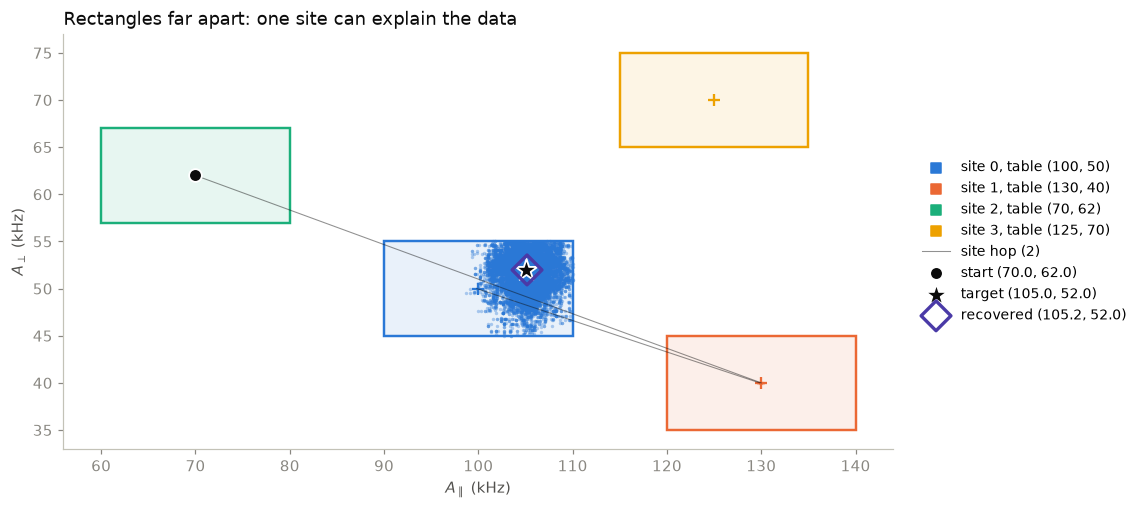

In [6]:
plot_coupling_space(apart, "Rectangles far apart: one site can explain the data")

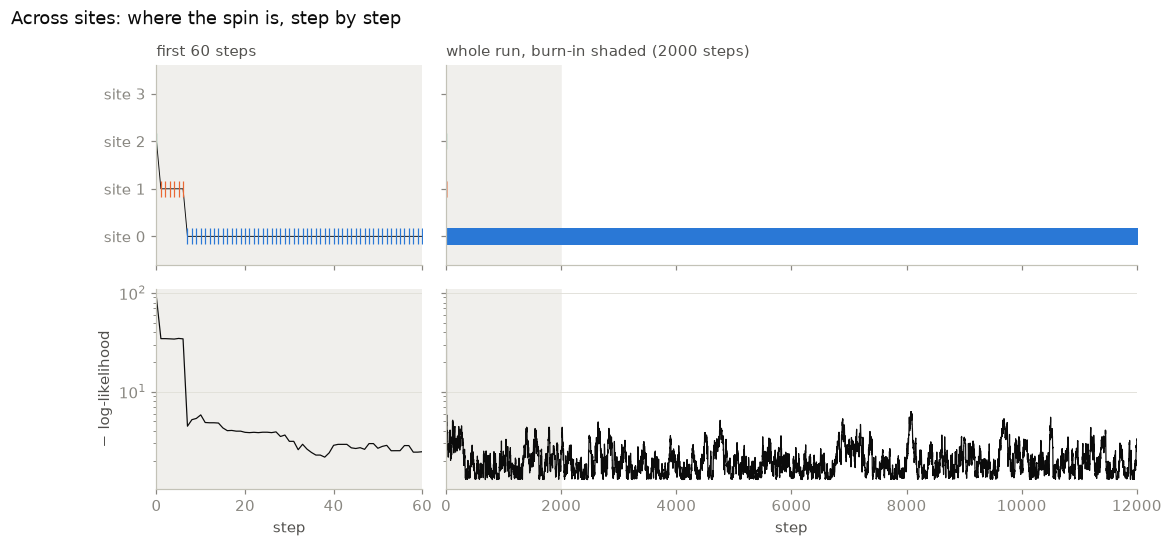

In [7]:
plot_across_sites(apart)

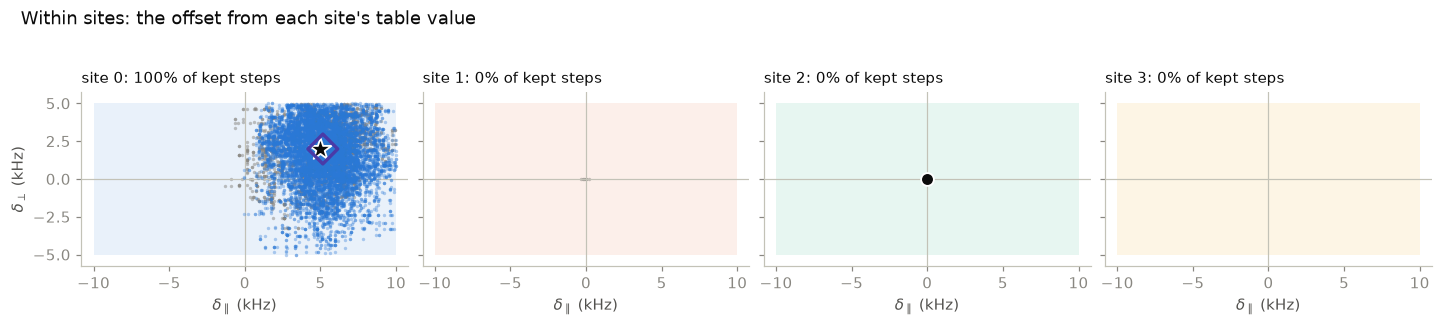

In [8]:
plot_within_sites(apart)

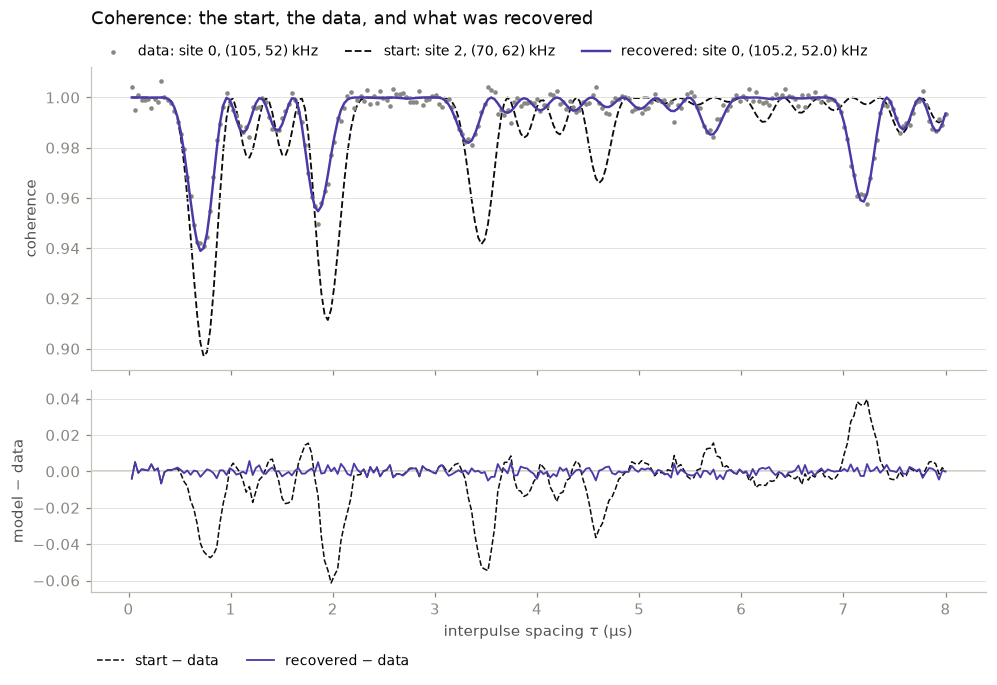

In [9]:
plot_signals(apart)

The spin hops twice in the opening steps, from site 2 to site 1 and then to
site 0, and never again. Once it is on the only site that can fit the data,
every proposed hop puts it on a site that cannot, and is rejected. After that the run is
the one-site walk of the previous notebook: the across-sites view is flat,
and all of the activity is in one panel of the within-sites view.

## 5. Rectangles that overlap

Now the table values lie close enough together that neighbouring rectangles
overlap. The target, (105, 52), is inside two of them: it is site 0 with an
offset of (+5, +2) and equally site 1 with an offset of (−4, −2). The walk
starts on site 3, which cannot reach it.

In [10]:
OVERLAPPING = [(100.0, 50.0), (109.0, 54.0), (88.0, 44.0), (118.0, 60.0)]
overlap = run_walk(OVERLAPPING, start_site=3, seed=0)
report(overlap)

site hops: 20 in 12000 steps (15 after burn-in)
share of steps after burn-in, by site: site 0: 65%, site 1: 35%, site 2: 0%, site 3: 0%
target   : site 0 at (105.00, 52.00) kHz
recovered: site 0 at (105.09, 51.94) kHz, offset (+5.09, +1.94), log-likelihood -1.29


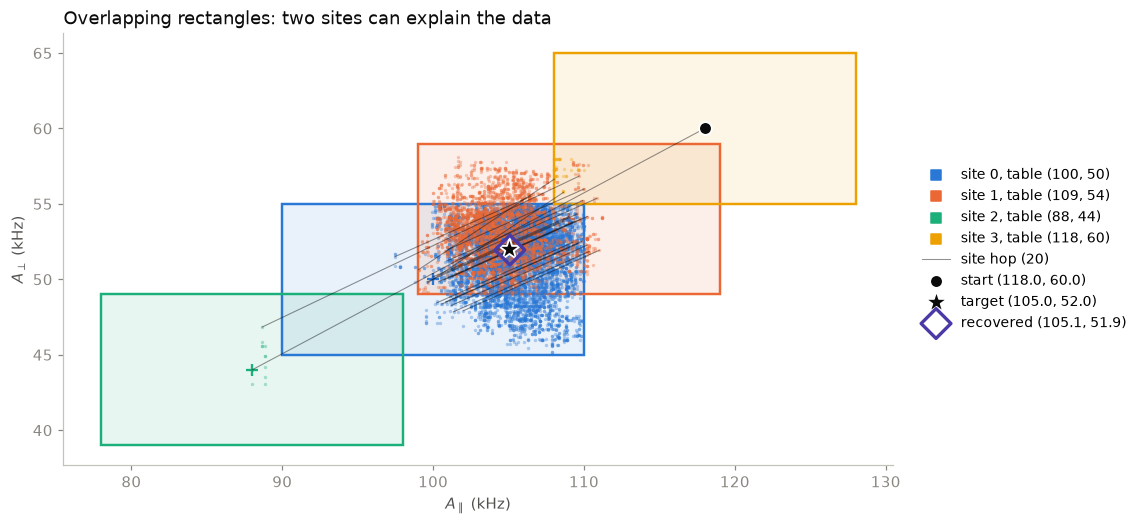

In [11]:
plot_coupling_space(overlap, "Overlapping rectangles: two sites can explain the data")

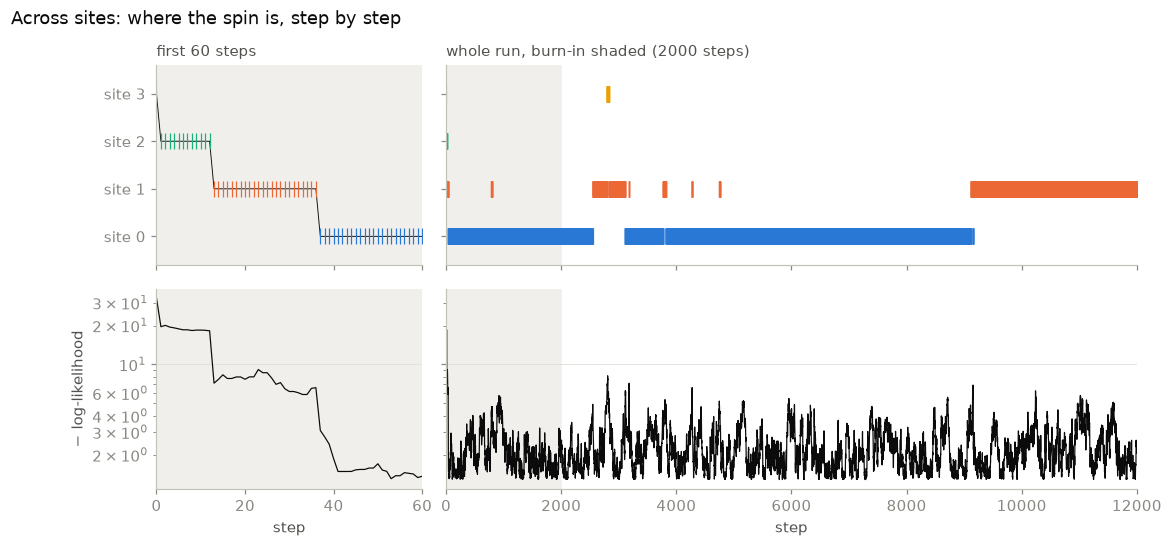

In [12]:
plot_across_sites(overlap)

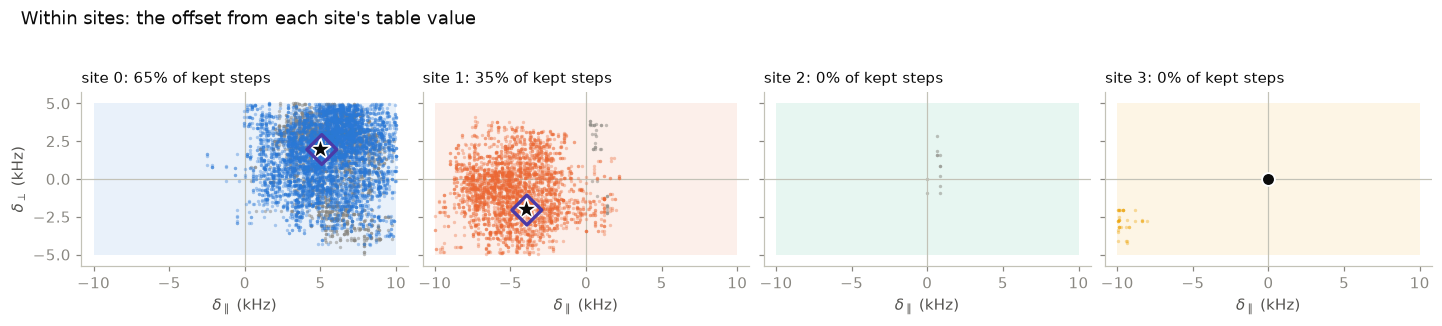

In [13]:
plot_within_sites(overlap)

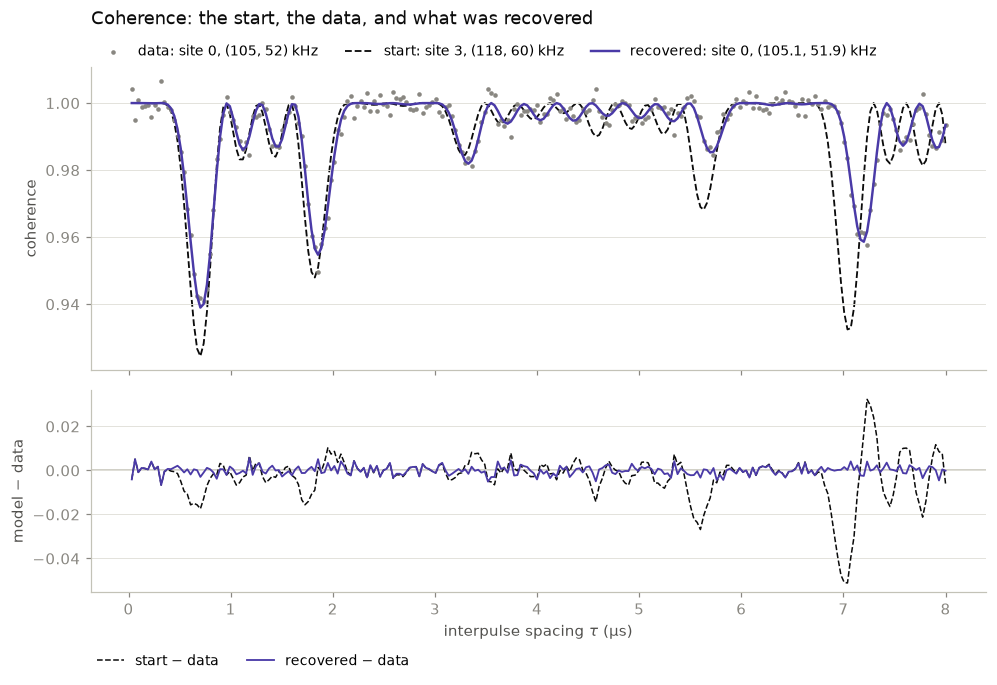

In [14]:
plot_signals(overlap)

The coupling is recovered as before, but the site is not. The spin reaches
site 0 by way of sites 2 and 1 in the opening steps, then keeps hopping
between site 0 and site 1 after burn-in, and in coupling space the
two clouds sit on top of each other at the target: the same coupling, reached
from two different table values. The data cannot tell those apart, and the
recovered site is whichever one the best sample happened to be on.

Two things to read off the within-sites view:

- The clouds on site 0 and site 1 are the same shape at different offsets,
  one centred near (+5, +2) and the other near (−4, −2).
- A hop carries the offset with it. A spin at (+5, +2) on site 0 lands at
  (+5, +2) on site 1, which is a coupling of (114, 56), not the target. The
  hop is accepted only when the offset happens to be somewhere both sites
  fit tolerably, which is why hops are rare and why the share of steps on
  each site varies from seed to seed. The split between the two sites in
  this run is not a converged estimate.
- Site 3 gets one brief visit after burn-in, pinned in the corner of its
  rectangle nearest the target. That corner, (108, 55), is 3 kHz from the
  target, which at four pulses is a poor fit but not an impossible one.